In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dateutil.relativedelta import relativedelta

In [82]:
# 1. Đường dẫn đến file (thay đổi theo tên file bạn đã tải)
file_path = './data/online_retail_II.xlsx' 

# 2. Load sheet thứ nhất (2009-2010)
df1 = pd.read_excel(file_path, sheet_name='Year 2009-2010')

# 3. Load sheet thứ hai (2010-2011)
df2 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

# 4. Gộp 2 sheet lại thành một DataFrame duy nhất
df = pd.concat([df1, df2], ignore_index=True)

print(f"Tổng số dòng sau khi gộp: {len(df)}")
df.head()

Tổng số dòng sau khi gộp: 1067371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.to_csv('./data/online_retail_II.csv', index=False)

In [70]:
df = pd.read_csv('./data/online_retail_II.csv')

In [ ]:
# --- BƯỚC 1: CLEANING & FORMATTING ---
df = df.rename(columns={'Price': 'unit_price'})
df = df.dropna(subset=['Customer ID', 'Description'])

# Chuẩn hóa định dạng dữ liệu
df['Customer ID'] = df['Customer ID'].astype(str).str.split('.').str[0]
df['Description'] = df['Description'].str.strip().str.upper()
df['StockCode'] = df['StockCode'].astype(str).str.strip()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()

# --- BƯỚC 2: ĐỊNH NGHĨA ĐƠN HỦY (CANCELED FLAG) ---
df['is_canceled'] = (
    df['Invoice'].astype(str).str.contains('C', na=False) | 
    (df['Quantity'] < 0)
).astype(int)

# --- BƯỚC 3: TÍNH TOÁN GIÁ TRỊ THỰC (MONETARY) ---
# valid_spend sẽ mang giá trị âm cho đơn hủy -> Khi sum() sẽ tự động tính Net Spend
df['valid_spend'] = df['Quantity'] * df['unit_price']

In [ ]:
def categorize_description(desc):
    if pd.isna(desc):
        return 'unknown'
    desc = str(desc).upper()
    
    # 1. Phí dịch vụ
    if any(k in desc for k in ['POSTAGE', 'MANUAL', 'CARRIAGE', 'DOTCOM', 'SERVICE']):
        return 'fees_services'

    # 2. Thời vụ & Tiệc tùng
    elif any(k in desc for k in ['CHRISTMAS', 'XMAS', 'SANTA', 'EASTER', 'BIRTHDAY', 'PARTY', 
                                 'GIFT TAGS', 'SLEIGH', 'BELLS', 'ADVENT', 'CALENDAR', 'WRAP', 
                                 'BALLOONS', 'RIBBON', 'HOLIDAY', 'BUNNIES', 'STRAWS', 'FLAGS', 
                                 'WATER BOMB', 'GARLAND', 'HONEYCOMB', 'WINDSOCK']):
        return 'seasonal'
    
    # 3. Nhà bếp & Ăn uống
    elif any(k in desc for k in ['CAKE', 'COFFEE', 'TEA', 'MUG', 'CUP', 'KITCHEN', 'BOWL', 'PLATE', 
                                 'POPCORN', 'BOTTLE', 'JAM', 'JAR', 'CUTTER', 'MOULD', 'NAPKIN', 
                                 'PANTRY', 'BREAD BIN', 'JUG', 'CUTLER', 'BEURRE', 'GLOVES', 
                                 'EGG HOLDER', 'FRYING PAN', 'COASTERS', 'FOOD COVER', 'EGG COSY',
                                 'TRAY', 'ENAMEL', 'COLANDER', 'TOADSTOOLS', 'SALT', 'PEPPER', 
                                 'PLATTER', 'POPSICLES', 'BEAKER', 'TONGS', 'SPOON', 'APRON', 
                                 'CHALICE', 'SUNDAE DISH', 'MICROWAVE', 'PIZZA SLICE', 'COCKTAIL SWORDS', 'WINE GLASS']):
        return 'kitchen_food'
    
    # 4. Trang trí nhà cửa
    elif any(k in desc for k in ['LIGHT', 'LAMP', 'CANDLE', 'DECOR', 'FRAME', 'PICTURE', 'SIGN', 
                                 'ORNAMENT', 'BLOCK', 'BOARD', 'DOORMAT', 'CLOCK', 'ALARM', 
                                 'CUSHION', 'STAR', 'RACK', 'LANTERN', 'SHELF', 'MAT', 'HOOK', 
                                 'PEARS', 'SLATE', 'FILLER PAD', 'MAGNETS', 'DOORSTOP', 
                                 'PHOTO CUBE', 'LED TORCH', 'MIRROR', 'MOBILE', 'WREATH', 
                                 'DISCO BALL', 'DOOR HANGER', 'OWLS', 'HANGING', 'CLOCHE', 
                                 'ZINC', 'WICKER', 'FOOT STOOL', 'WALL ART', 'MAGNET', 
                                 'HOME SWEET HOME', 'CURTAIN', 'P\'WEIGHT', 'JEWELLERY STAND', 
                                 'VASE', 'INCENSE', 'POSY']):
        return 'home_decor'
    
    # 5. Văn phòng phẩm & Thủ công
    elif any(k in desc for k in ['PENCILS', 'FELTCRAFT', 'SEWING', 'KIT', 'PAPER', 'CARD', 'ENVELOPE', 
                                 'STICKER', 'NOTEBOOK', 'CRAYONS', 'CHALK', 'TISSUES', 'CLAY', 
                                 'STENCIL', 'PEN', 'CANVAS', 'ERASERS', 'EXERCISE BOOKS', 
                                 'TISSUE REAM', 'STATIONERY', 'CALCULATOR', 'SKETCHBOOK', 
                                 'JOURNAL', 'STAMP SET', 'SHOPPING LIST', 'MEASURING TAPE', 
                                 'SCISSOR', 'BADGES', 'LETTER HOLDER', 'IRON ON PATCHES']):
        return 'stationery_craft'

    # 6. Đồ chơi & Quà tặng trẻ em
    elif any(k in desc for k in ['TOY', 'SPINNING TOP', 'BINGO', 'PLAYHOUSE', 'GAME', 'DOLL', 
                                 'PUZZLE', 'CHILDS', 'SPACEBOY', 'CIRCUS', 'DRAWING SLATE', 
                                 'TATTOOS', 'LUDO', 'BEACH SPADE', 'TEDDY BEAR', 'SKULL', 
                                 'JIGSAW', 'DINOSAUR', 'MONEY BANK', 'NAUGHTS & CROSSES', 
                                 'CREEPY CRAWLIES', 'BUBBLEGUM RING', 'TOAST ITS', 
                                 'WHEELBARROW', 'RAIN MAC', 'ROCKING HORSE', 'NURSERY', 'KIDS', 
                                 'TREASURE CHEST', 'SNAKE', 'PUPPET', 'RACING CAR', 'FLYING DISC', 
                                 'ICE CREAM BUBBLES', 'JUMPER', 'DRESS', 'BIB', 'BABY', 
                                 'HELICOPTER', 'CANARY', 'RABBIT', 'SINGING', 'DOLPHINS', 'GLOW']):
        return 'toys_gifts'
    
    # 7. Túi xách & Lưu trữ
    elif any(k in desc for k in ['BAG', 'CASE', 'HOLDALL', 'LUNCH', 'JUMBO', 'STORAGE', 'BASKET', 
                                 'TIN', 'BOX', 'TIDY', 'PURSE', 'LUGGAGE', 'PASSPORT', 'TAG', 'COVER', 'BACKPACK']):
        return 'storage_bags'
    
    # 8. Phụ kiện & Cá nhân
    elif any(k in desc for k in ['PARASOL', 'WARMER', 'NECKLACE', 'BRACELET', 'EARRINGS', 
                                 'UMBRELLA', 'KEY FOB', 'FAN', 'BUTTERFLY', 'CLIPS', 
                                 'LIP GLOSS', 'KEYRING', 'SOAP HOLDER', 'SPONGE', 'BATH', 
                                 'SOAP DISH', 'BICYCLE BELL', 'HAT', 'SHOES', 'KEY HOLDER', 
                                 'PONCHO', 'FLY SWAT', 'SOCK']):
        return 'accessories'
    
    # 9. Sân vườn & Ngoài trời
    elif any(k in desc for k in ['GARDEN', 'KNEELING PAD', 'PLANT', 'POT', 'WATERING CAN', 
                                 'HAMMOCK', 'HERB MARKER', 'BIRDHOUSE', 'HERBS', 'SPIRIT LEVEL']):
        return 'garden_outdoor'

    # 10. Nội thất & Đồ gỗ
    elif any(k in desc for k in ['CABINET', 'DRAWER', 'WOOD', 'FURNITURE', 'TABLE', 'CHAIR', 'STOOL']):
        return 'furniture'
    
    # 11. Phong cách Design
    elif any(k in desc for k in ['HEART', 'VINTAGE', 'RETRO', 'DESIGN', 'FLOWER', 
                                 'STRAWBERRY', 'CHARM', 'RIBBONS', 'FLYING DUCKS', 'SCREWDRIVER', 
                                 'FOLK', 'CROCHETED', 'PAISLEY', 'ABSTRACT', 'SOMBRERO', 
                                 'REGENCY', 'POLKADOT', 'PORCELAIN', 'ROSE']):
        return 'design_vintage'
    
    else:
        return 'other'

In [160]:
# Xem top 20 sản phẩm nằm trong nhóm 'other'
top_others = df_master[df_master['category'] == 'other']['Description'].value_counts().head(20)
print(top_others)

Description
CARROT CHARLIE+LOLA COASTER SET      157
EIGHT PIECE CREEPY CRAWLIE SET       128
ETCHED GLASS COASTER                 118
GOLD MINI TAPE MEASURE               102
FELT FARM ANIMAL WHITE BUNNY          90
KEY RING BASEBALL BOOT ASSORTED       88
KEY RING BASEBALL BOOT UNION JACK     87
FELT FARM ANIMAL CHICKEN              86
GREEN METAL SWINGING BUNNY            81
6 CROCHET STRAWBERRIES                72
SILVER MINI TAPE MEASURE              68
PACK 3 IRON ON DOG PATCHES            66
WHITE SNOW SCANDINAVIAN STOCKING      65
CUTE CATS TAPE                        65
GREEN MINI TAPE MEASURE               65
HAWAIIAN GRASS SKIRT                  64
PACK 3 FIRE ENGINE/CAR PATCHES        63
BLACK MINI TAPE MEASURE               63
STRING OF 8 BUTTERFLIES,PINK          62
DOGGY RUBBER                          62
Name: count, dtype: int64


In [73]:
# Phân loại ngành hàng
df['category'] = df['Description'].apply(categorize_description)

# --- BƯỚC 4: LỌC MÃ RÁC NHƯNG GIỮ ĐƠN HỦY THẬT ---
service_codes = ['POST', 'D', 'M', 'C2', 'BANK CHARGES', 'DOT', 'CRUK', 'PADS', 'ADJUST']
df = df[~df['StockCode'].isin(service_codes)]
df = df[~df['Description'].str.contains('TEST PRODUCT', na=False)]

# CHỐT HẠ: Chỉ loại bỏ nếu giá <= 0 VÀ không phải đơn hủy
# Điều này giữ lại các dòng đơn hủy (is_canceled=1) để tính tỷ lệ hủy đơn
df_master = df[(df['unit_price'] > 0) | (df['is_canceled'] == 1)].copy()

# Loại bỏ dòng trùng lặp
df_master = df_master.drop_duplicates()

print(f"✅ Kích thước Master Table: {df_master.shape}")
print(f"✅ Số lượng khách hàng: {df_master['Customer ID'].nunique()}")
print(f"✅ Số lượng dòng đơn hủy được giữ lại: {df_master['is_canceled'].sum()}")

✅ Kích thước Master Table: (794166, 11)
✅ Số lượng khách hàng: 5875
✅ Số lượng dòng đơn hủy được giữ lại: 17586


In [74]:
df_master.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'unit_price', 'Customer ID', 'Country', 'valid_spend', 'is_canceled',
       'category'],
      dtype='object')

In [ ]:
df_master.to_csv('./data/synthetic_data.csv', index=False)

Tiền xử lý trước khi tạo snapshot

In [2]:
df_master = pd.read_csv('./data/synthetic_data.csv', parse_dates=['InvoiceDate'])

In [3]:
# --- BƯỚC 1: XỬ LÝ OUTLIERS (CHỈ CAP GIÁ TRỊ DƯƠNG) ---
# Chúng ta chỉ giới hạn các đơn hàng quá lớn (outliers dương), 
# nhưng giữ nguyên các giá trị âm (đơn hủy) để tính Net Spend chính xác.
cap_spend = df_master[df_master['valid_spend'] > 0]['valid_spend'].quantile(0.99)
cap_qty   = df_master[df_master['Quantity'] > 0]['Quantity'].quantile(0.99)

# Clip: Giá trị tối thiểu là None (giữ nguyên số âm), giá trị tối đa là mức 99th
df_master['valid_spend_capped'] = np.clip(df_master['valid_spend'], None, cap_spend)
df_master['Quantity_capped']    = np.clip(df_master['Quantity'], None, cap_qty)

In [4]:
# Log transform: Chỉ áp dụng cho số dương (Quantity > 0)
# Với đơn hủy, set log_qty = 0 vì đã có cột is_canceled để track
df_master['log_qty'] = df_master['Quantity_capped'].apply(lambda x: np.log1p(x) if x > 0 else 0)

In [5]:
# --- BƯỚC 2: CẬP NHẬT GROUPBY TRANSACTION ---
order_df = df_master.groupby(
    ['Customer ID', 'Invoice', 'InvoiceDate']
).agg(
    # Doanh thu thuần: Tự động trừ đơn hủy nhờ giữ nguyên số âm
    order_value = ('valid_spend_capped', 'sum'),
    
    # Tín hiệu hủy đơn: 1 nếu có bất kỳ dòng nào bị hủy, 0 nếu thành công
    is_canceled = ('is_canceled', 'max'),
    
    # Đặc trưng hành vi
    total_items = ('Quantity_capped', 'sum'),
    log_items   = ('log_qty', 'sum'),
    n_lines     = ('StockCode', 'count'),
    n_category  = ('category', 'nunique'),
    country     = ('Country', 'first')
).reset_index()

# Tạo biến định lượng tiền hủy để Preprocessor tính toán dễ hơn
order_df['canceled_value'] = order_df.apply(
    lambda x: abs(x['order_value']) if x['is_canceled'] == 1 else 0, axis=1
)

In [6]:
order_df.to_csv('./data/synthetic_data.csv', index=False)

In [8]:
order_df.head()

,Customer ID,Invoice,InvoiceDate,order_value,is_canceled,total_items,log_items,n_lines,n_category,country,canceled_value
0,12346,499763,2010-03-02,27.05,0,5,3.465736,5,2,United Kingdom,0.0
1,12346,513774,2010-06-28,142.31,0,19,13.169796,19,3,United Kingdom,0.0
2,12346,541431,2011-01-18,201.60,0,144,4.976734,1,1,United Kingdom,0.0
3,12346,C541433,2011-01-18,-77183.60,1,-74215,0.000000,1,1,United Kingdom,77183.6
4,12347,529924,2010-10-31,611.53,0,509,99.422509,40,6,Iceland,0.0


In [9]:
transaction = pd.read_csv('./data/synthetic_data.csv', parse_dates=['InvoiceDate'])

In [10]:
transaction.head()

,Customer ID,Invoice,InvoiceDate,order_value,is_canceled,total_items,log_items,n_lines,n_category,country,canceled_value
0,12346,499763,2010-03-02,27.05,0,5,3.465736,5,2,United Kingdom,0.0
1,12346,513774,2010-06-28,142.31,0,19,13.169796,19,3,United Kingdom,0.0
2,12346,541431,2011-01-18,201.60,0,144,4.976734,1,1,United Kingdom,0.0
3,12346,C541433,2011-01-18,-77183.60,1,-74215,0.000000,1,1,United Kingdom,77183.6
4,12347,529924,2010-10-31,611.53,0,509,99.422509,40,6,Iceland,0.0


In [11]:
transaction.columns

Index(['Customer ID', 'Invoice', 'InvoiceDate', 'order_value', 'is_canceled',
       'total_items', 'log_items', 'n_lines', 'n_category', 'country',
       'canceled_value'],
      dtype='str')

In [14]:
transaction = transaction.rename(columns={
    'Customer ID': 'Customer_id',
    'Invoice': 'Order_id',
    'InvoiceDate': 'Order_date',
    'Order_items_log_sum': 'Total_items',
    'n_lines': 'Order_n_lines',
    'n_category': 'Order_n_categories',
    'country': 'Country',
    'order_value': 'Order_value',
    'is_canceled': 'Is_canceled',
    'canceled_value': 'Canceled_value',
    'log_items': 'Log_items',
    'total_items': 'Total_items'
})

In [15]:
transaction.columns

Index(['Customer_id', 'Order_id', 'Order_date', 'Order_value', 'Is_canceled',
       'Total_items', 'Log_items', 'Order_n_lines', 'Order_n_categories',
       'Country', 'Canceled_value'],
      dtype='str')

In [ ]:
transaction.to_csv("./data/processed_data.csv", index=False)

Tạo snapshot

In [2]:
transaction = pd.read_csv('./data/processed_data.csv', parse_dates=['Order_date'])

In [3]:
monthly_orders = (
    transaction
    .groupby(transaction['Order_date'].dt.to_period('M'))
    ['Order_id']
    .nunique()
    .sort_index()
)

monthly_orders = monthly_orders.to_timestamp()

monthly_orders = monthly_orders[monthly_orders.index < '2011-12-01']

In [4]:
rolling_mean = monthly_orders.rolling(3).mean()

threshold = rolling_mean.quantile(0.4)

stable_months = rolling_mean[rolling_mean > threshold].index

In [5]:
stable_start = stable_months.min()
stable_end   = stable_months.max()

print("Stable period:", stable_start, "→", stable_end)

Stable period: 2010-05-01 00:00:00 → 2011-11-01 00:00:00


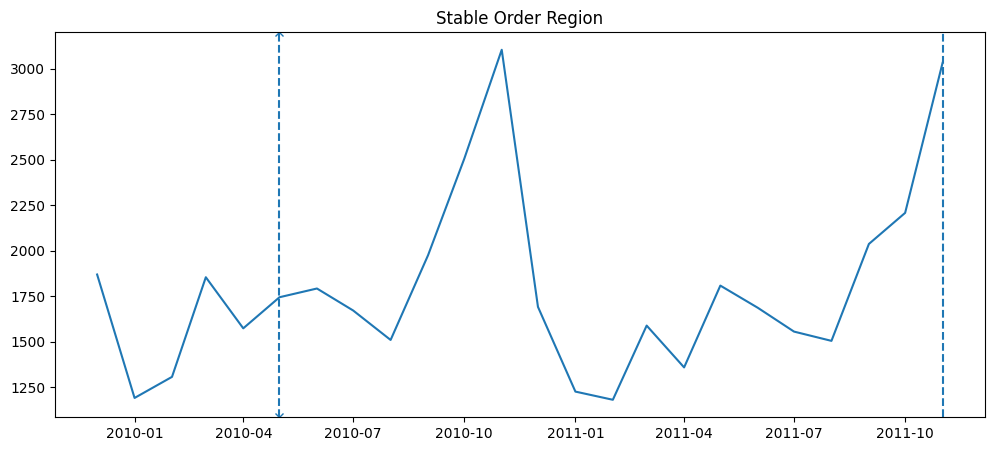

In [21]:
plt.figure(figsize=(12,5))
plt.plot(monthly_orders.index, monthly_orders.values)

plt.axvline(stable_start, linestyle='--', marker='x')
plt.axvline(stable_end, linestyle='--')

plt.title("Stable Order Region")
plt.show()

--- PHÂN TÍCH CHỌN OBSERVATION WINDOW ---
Nếu chọn Obs Window 90 ngày: Bao phủ được 85.2% hành vi mua lại của khách.
Nếu chọn Obs Window 120 ngày: Bao phủ được 90.2% hành vi mua lại của khách.
Nếu chọn Obs Window 150 ngày: Bao phủ được 93.3% hành vi mua lại của khách.
Nếu chọn Obs Window 180 ngày: Bao phủ được 95.3% hành vi mua lại của khách.


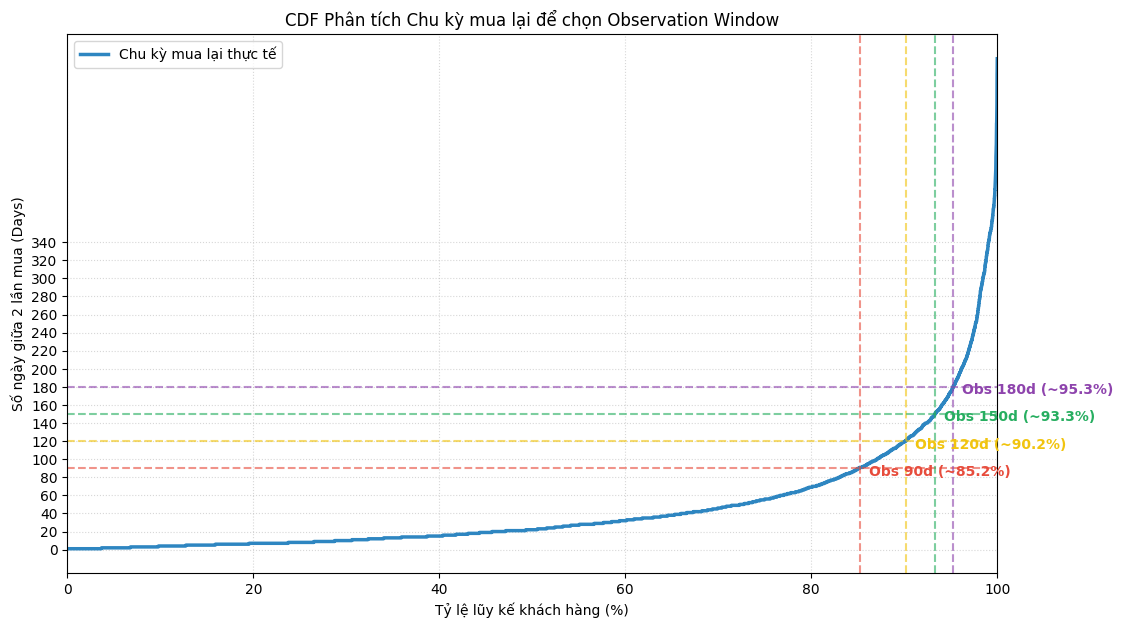

In [6]:
# 1. Lọc vùng ổn định
df_stable = transaction[
    (transaction['Order_date'] >= stable_start) & 
    (transaction['Order_date'] <= stable_end)
].copy()

# 2. Tính khoảng cách mua lại (giữ nguyên logic của bạn)
df_stable = df_stable.sort_values(['Customer_id', 'Order_date'])
df_stable['prev_date'] = df_stable.groupby('Customer_id')['Order_date'].shift(1)
df_stable['days_between'] = (df_stable['Order_date'] - df_stable['prev_date']).dt.days

# 3. Lọc lấy dữ liệu mua lại thực tế
repurchase_stable = df_stable['days_between'].dropna()
repurchase_stable = repurchase_stable[repurchase_stable > 0]

# --- PHÂN TÍCH ĐỂ CHỌN OBS WINDOW ---
repurchase_sorted = np.sort(repurchase_stable.values)
percentiles = np.linspace(0, 100, len(repurchase_sorted))

# Hàm tìm Percentile cho một mốc ngày cụ thể
def get_p(d):
    return (repurchase_sorted <= d).mean() * 100

# Các mốc ứng viên cho Obs Window (Quá khứ)
obs_candidates = [90, 120, 150, 180] 

print(f"--- PHÂN TÍCH CHỌN OBSERVATION WINDOW ---")
for d in obs_candidates:
    print(f"Nếu chọn Obs Window {d} ngày: Bao phủ được {get_p(d):.1f}% hành vi mua lại của khách.")

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 7))
plt.plot(percentiles, repurchase_sorted, color='#2E86C1', linewidth=2.5, label='Chu kỳ mua lại thực tế')

# Vẽ các đường gợi ý cho Obs Window
colors = ['#E74C3C', '#F1C40F', '#27AE60', '#8E44AD']
for i, d in enumerate(obs_candidates):
    p = get_p(d)
    plt.axhline(y=d, color=colors[i], linestyle='--', alpha=0.6)
    plt.axvline(x=p, color=colors[i], linestyle='--', alpha=0.6)
    plt.text(p + 1, d - 8, f'Obs {d}d (~{p:.1f}%)', color=colors[i], fontweight='bold')

plt.xlabel("Tỷ lệ lũy kế khách hàng (%)")
plt.ylabel("Số ngày giữa 2 lần mua (Days)")
plt.title("CDF Phân tích Chu kỳ mua lại để chọn Observation Window")

# Chỉnh trục Y cho chi tiết hơn
plt.yticks(np.arange(0, 360, 20))
plt.xlim(0, 100)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

Biểu đồ tăng trưởng mạnh, chọn Obs Window 150 ngày bao phủ được hơn 90% hành vi mua lại của khách.

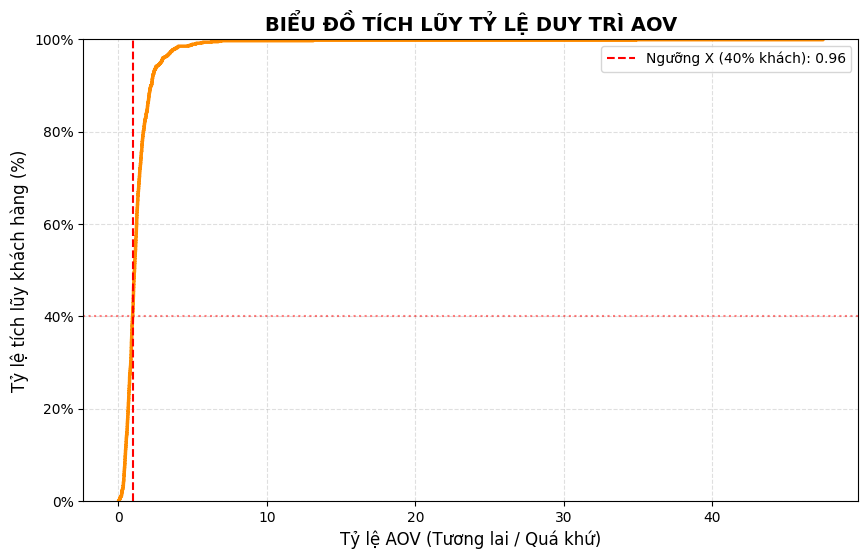

In [18]:
snapshot_date = stable_start + pd.DateOffset(months=5) - pd.Timedelta(days=1)

# --- SỬA LẠI: Lọc chỉ lấy đơn hàng thành công (Doanh thu dương) ---
valid_txn = transaction[transaction['Order_value'] > 0]

# Khai báo past_data (Dữ liệu quan sát)
past_data = valid_txn[(valid_txn['Order_date'] >= stable_start) & 
                        (valid_txn['Order_date'] <= snapshot_date)]

# Khai báo future_data (Dữ liệu thực tế tháng tiếp theo)
future_data = valid_txn[(valid_txn['Order_date'] > snapshot_date) & 
                          (valid_txn['Order_date'] <= snapshot_date + pd.Timedelta(days=30))]

# --- 1. TÍNH TOÁN AOV TRỰC TIẾP ---
# Vì mỗi dòng là 1 Order, nên mean() chính là AOV (Average Order Value)
aov_past = past_data.groupby('Customer_id')['Order_value'].mean().to_frame(name='aov_past')

aov_future = future_data.groupby('Customer_id')['Order_value'].mean().to_frame(name='aov_future')

# --- 2. SO SÁNH VÀ TÍNH TỶ LỆ (RATIO) ---
aov_compare = aov_past.join(aov_future, how='inner')

# Tỷ lệ biến thiên: Chi tiêu tháng tới / Chi tiêu trung bình quá khứ
aov_compare['aov_ratio'] = aov_compare['aov_future'] / aov_compare['aov_past']

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=aov_compare, x='aov_ratio', color='darkorange', linewidth=2.5)

# Tìm ngưỡng X tại mốc 20% 
# Tức là tìm giá trị Ratio mà 20% khách hàng quay lại nằm dưới hoặc bằng mốc đó
x_aov_threshold = aov_compare['aov_ratio'].quantile(0.4)

plt.axvline(x_aov_threshold, color='red', linestyle='--', 
            label=f'Ngưỡng X (40% khách): {x_aov_threshold:.2f}')
plt.axhline(0.4, color='red', linestyle=':', alpha=0.5)

plt.title('BIỂU ĐỒ TÍCH LŨY TỶ LỆ DUY TRÌ AOV', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ AOV (Tương lai / Quá khứ)', fontsize=12)
plt.ylabel('Tỷ lệ tích lũy khách hàng (%)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

Dựa vào biểu đồ mật độ tích lũy (ECDF), mức Ratio = 0.9 là điểm gãy quan trọng. Tại mức này, chúng ta tách biệt được 60% nhóm khách hàng có quay lại nhưng vẫn giữ vững phong độ chi tiêu. Việc chọn ngưỡng cao (0.9 thay vì 0.5 hay 0.6) giúp loại bỏ những khách hàng "mua cho có" hoặc những đơn hàng giá trị thấp không mang lại lợi nhuận thực tế.

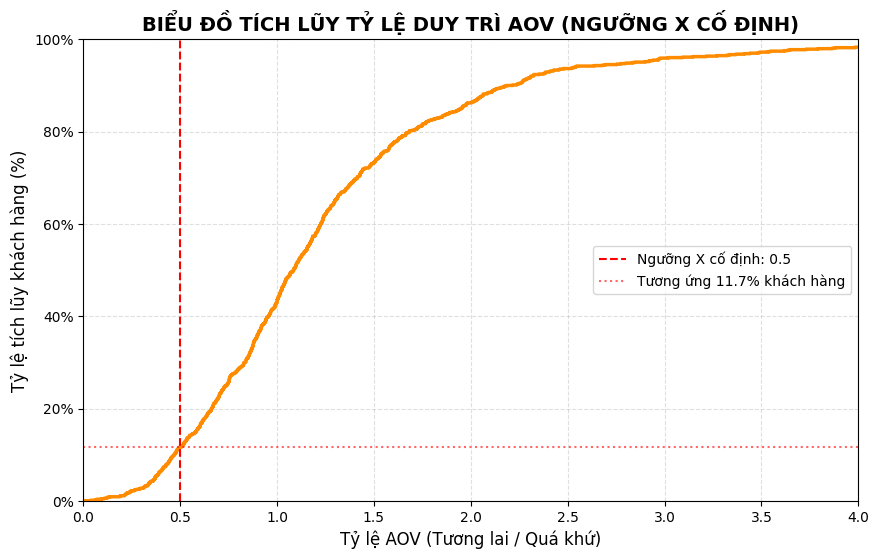

Với ngưỡng Ratio >= 0.5:
 - Có 88.3% khách hàng quay lại đạt chuẩn (Nhãn 1)
 - Có 11.7% khách hàng quay lại không đạt chuẩn (Nhãn 0)


In [108]:
import matplotlib.ticker as mticker

# --- THIẾT LẬP NGƯỠNG X CỐ ĐỊNH THEO Ý MUỐN ---
# Bạn có thể thay con số 0.9 này bằng bất kỳ mức Ratio nào bạn muốn (ví dụ 1.0, 0.8, ...)
x_fixed_threshold = 0.5 

snapshot_date = stable_start + pd.DateOffset(months=5) - pd.Timedelta(days=1)

# --- 1. LỌC VÀ CHUẨN BỊ DỮ LIỆU ---
valid_txn = transaction[transaction['Order_value'] > 0]

past_data = valid_txn[(valid_txn['Order_date'] >= stable_start) & 
                        (valid_txn['Order_date'] <= snapshot_date)]

future_data = valid_txn[(valid_txn['Order_date'] > snapshot_date) & 
                          (valid_txn['Order_date'] <= snapshot_date + pd.Timedelta(days=30))]

aov_past = past_data.groupby('Customer_id')['Order_value'].mean().to_frame(name='aov_past')
aov_future = future_data.groupby('Customer_id')['Order_value'].mean().to_frame(name='aov_future')

# Join inner để lấy những người có quay lại mua hàng (để vẽ biểu đồ)
aov_compare = aov_past.join(aov_future, how='inner')
aov_compare['aov_ratio'] = aov_compare['aov_future'] / aov_compare['aov_past']

# --- 2. TÍNH TOÁN TỶ LỆ PHẦN TRĂM TƯƠNG ỨNG VỚI X ---
# Tính xem có bao nhiêu % khách hàng nằm dưới ngưỡng x_fixed_threshold này
y_percent = (aov_compare['aov_ratio'] <= x_fixed_threshold).mean()

# --- 3. VẼ BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
# Giới hạn trục X ở mức 95th percentile để biểu đồ không bị loãng bởi Outliers
plt.xlim(0, 4)
sns.ecdfplot(data=aov_compare, x='aov_ratio', color='darkorange', linewidth=2.5)

# Vẽ đường thẳng đứng tại ngưỡng X cố định
plt.axvline(x_fixed_threshold, color='red', linestyle='--', 
            label=f'Ngưỡng X cố định: {x_fixed_threshold}')

# Vẽ đường nằm ngang tại tỷ lệ % tương ứng
plt.axhline(y_percent, color='red', linestyle=':', alpha=0.6,
            label=f'Tương ứng {y_percent*100:.1f}% khách hàng')

plt.title('BIỂU ĐỒ TÍCH LŨY TỶ LỆ DUY TRÌ AOV (NGƯỠNG X CỐ ĐỊNH)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ AOV (Tương lai / Quá khứ)', fontsize=12)
plt.ylabel('Tỷ lệ tích lũy khách hàng (%)', fontsize=12)

# Định dạng trục Y thành %
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

print(f"Với ngưỡng Ratio >= {x_fixed_threshold}:")
print(f" - Có {(1 - y_percent)*100:.1f}% khách hàng quay lại đạt chuẩn (Nhãn 1)")
print(f" - Có {y_percent*100:.1f}% khách hàng quay lại không đạt chuẩn (Nhãn 0)")

Áp dụng ngưỡng: hoạt động liên tiếp ít nhất 2 tháng 

In [19]:
import pandas as pd
from dateutil.relativedelta import relativedelta

def has_2_consecutive_months(order_dates):
    """
    Kiểm tra xem danh sách ngày đơn hàng có chứa ít nhất 2 tháng liên tiếp không
    """
    if len(order_dates) < 2:
        return False
    
    # Lấy các tháng duy nhất và sắp xếp
    months = sorted(set([d.to_period('M') for d in order_dates]))
    
    if len(months) < 2:
        return False
    
    # Kiểm tra có 2 tháng liên tiếp không
    for i in range(len(months) - 1):
        if (months[i+1] - months[i]).n == 1:
            return True
    
    return False

def create_rolling_snapshot(df):
    df['Order_date'] = pd.to_datetime(df['Order_date'])
    snapshot_dates = pd.date_range(start='2010-09-30', end='2011-10-31', freq='ME')
    
    all_snapshots = []

    for s_date in snapshot_dates:
        print(f"--- Đang xử lý Snapshot: {s_date.date()} ---")
        
        obs_start = s_date - relativedelta(months=5)
        future_end = s_date + relativedelta(months=1)
        
        past_df = df[(df['Order_date'] > obs_start) & 
                     (df['Order_date'] <= s_date) &
                     (df['Is_canceled'] == 0)].copy()

        future_df = df[(df['Order_date'] > s_date) & 
                       (df['Order_date'] <= future_end) &
                       (df['Is_canceled'] == 0)].copy()
        
        if past_df.empty:
            continue
        
        # Kiểm tra 2 tháng liên tiếp
        customer_groups = past_df.groupby('Customer_id')
        valid_customers = []
        
        for customer_id, group in customer_groups:
            order_dates = group['Order_date'].tolist()
            if has_2_consecutive_months(order_dates):
                valid_customers.append(customer_id)
        
        if len(valid_customers) == 0:
            print(f"Không có khách hàng nào có 2 tháng liên tiếp")
            continue
        
        past_df_filtered = past_df[past_df['Customer_id'].isin(valid_customers)].copy()
        
        past_features = past_df_filtered.groupby('Customer_id').agg(
            AOV_5m=('Order_value', 'mean'),
            total_orders_5m=('Order_value', 'count'),
            active_months_count=('Order_date', lambda x: x.dt.to_period('M').nunique())
        )
        
        future_features = future_df.groupby('Customer_id').agg(
            AOV_Future=('Order_value', 'mean')
        )
        
        snapshot_result = past_features.join(future_features, how='left').fillna(0)
        
        x_threshold = 0.5
        snapshot_result['aov_ratio'] = snapshot_result['AOV_Future'] / snapshot_result['AOV_5m']
        snapshot_result['label'] = (snapshot_result['aov_ratio'] >= x_threshold).astype(int)
        snapshot_result['snapshot_date'] = s_date
        
        snap_base = snapshot_result.reset_index()[['Customer_id', 'snapshot_date', 'label']]

        all_snapshots.append(snap_base)
        
        total = len(snap_base)
        pos = snap_base['label'].sum()
        print(f"Hoàn thành: {total} khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: {pos} ({pos/total*100:.1f}%)")

    if not all_snapshots:
        return pd.DataFrame()
        
    final_df = pd.concat(all_snapshots, ignore_index=True)
    return final_df

In [20]:
snapshot_data = create_rolling_snapshot(transaction)

--- Đang xử lý Snapshot: 2010-09-30 ---
Hoàn thành: 774 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 380 (49.1%)
--- Đang xử lý Snapshot: 2010-10-31 ---
Hoàn thành: 861 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 465 (54.0%)
--- Đang xử lý Snapshot: 2010-11-30 ---
Hoàn thành: 1051 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 366 (34.8%)
--- Đang xử lý Snapshot: 2010-12-31 ---
Hoàn thành: 1121 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 361 (32.2%)
--- Đang xử lý Snapshot: 2011-01-31 ---
Hoàn thành: 1062 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 295 (27.8%)
--- Đang xử lý Snapshot: 2011-02-28 ---
Hoàn thành: 997 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 307 (30.8%)
--- Đang xử lý Snapshot: 2011-03-31 ---
Hoàn thành: 771 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 299 (38.8%)
--- Đang xử lý Snapshot: 2011-04-30 ---
Hoàn thành: 628 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 321 (51.1%)
--- Đang xử lý Snapshot: 2011-05-31 ---
Hoàn thành: 644 khách hàng (>=2 tháng LIÊN TIẾP) | Nhãn 1: 316 (49.1%

--- BẢNG THỐNG KÊ NHÃN ---
       Số lượng  Tỷ lệ (%)
label                     
0          6822  57.332549
1          5077  42.667451
------------------------------


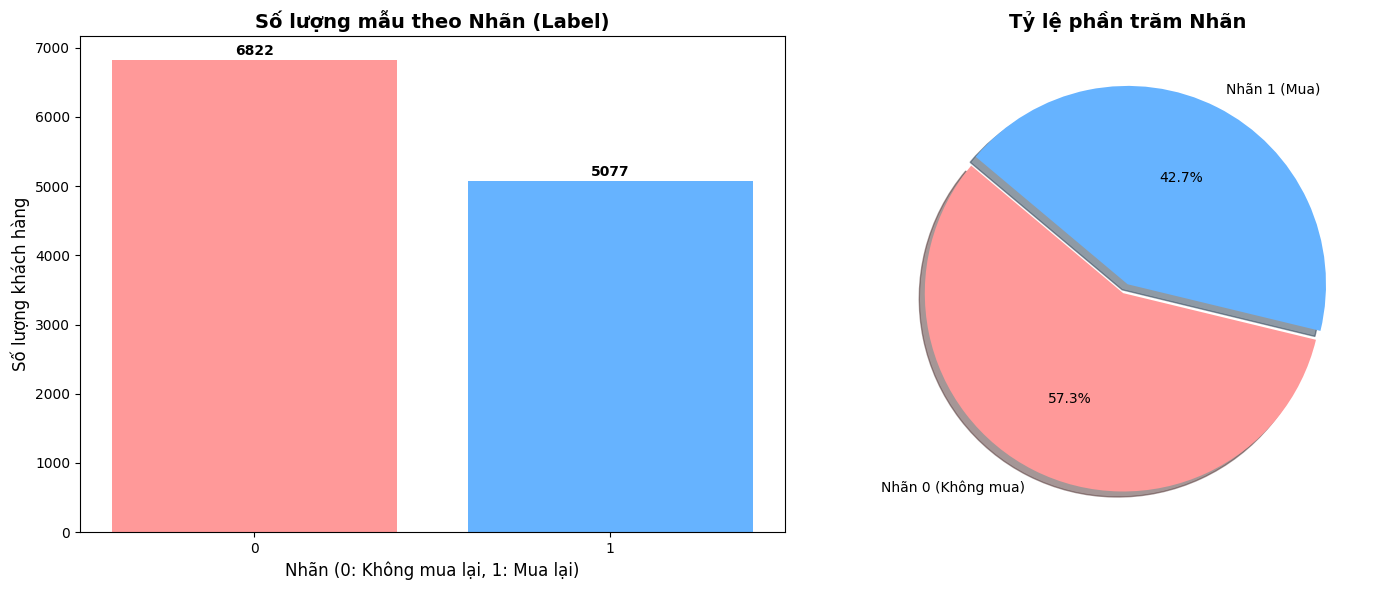

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_label_distribution(df):
    """
    Thống kê và trực quan hóa tỷ lệ nhãn 0 và 1 sau khi Rolling Snapshot.
    """
    # 1. Tính toán số lượng và tỷ lệ % - sắp xếp theo thứ tự 0, 1
    counts = df['label'].value_counts().sort_index()  # Thêm sort_index()
    percentages = df['label'].value_counts(normalize=True).sort_index() * 100
    
    # Tạo bảng thống kê nhanh
    stats_df = pd.DataFrame({
        'Số lượng': counts,
        'Tỷ lệ (%)': percentages
    })
    
    print("--- BẢNG THỐNG KÊ NHÃN ---")
    print(stats_df)
    print("-" * 30)

    # 2. Vẽ biểu đồ Bar Chart & Pie Chart
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Biểu đồ cột - đảm bảo thứ tự 0, 1
    colors = ['#ff9999', '#66b3ff']  # 0: đỏ, 1: xanh
    bars = ax[0].bar(counts.index, counts.values, color=[colors[i] for i in counts.index])
    ax[0].set_title('Số lượng mẫu theo Nhãn (Label)', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Nhãn (0: Không mua lại, 1: Mua lại)', fontsize=12)
    ax[0].set_ylabel('Số lượng khách hàng', fontsize=12)
    ax[0].set_xticks([0, 1])
    
    # Thêm giá trị lên đầu cột
    for i, (idx, v) in enumerate(counts.items()):
        ax[0].text(idx, v + (max(counts.values)*0.01), str(v), ha='center', fontweight='bold')

    # Biểu đồ tròn - đảm bảo thứ tự đúng
    ax[1].pie([counts[0], counts[1]], 
              labels=['Nhãn 0 (Không mua)', 'Nhãn 1 (Mua)'], 
              autopct='%1.1f%%', 
              startangle=140, 
              colors=['#ff9999','#66b3ff'], 
              explode=(0.05, 0), 
              shadow=True)
    ax[1].set_title('Tỷ lệ phần trăm Nhãn', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

analyze_label_distribution(snapshot_data)

Feature Engineering

In [ ]:
# from sklearn.preprocessing import RobustScaler

# def build_online_retail_features(transaction, snapshot_base):
#     df = transaction.copy()
#     df['Order_date'] = pd.to_datetime(df['Order_date'])
    
#     has_category = 'category' in df.columns
#     result = []
    
#     # ========== FIT ROBUSTSCALER TRÊN TOÀN BỘ DATA ==========
#     # Lấy tất cả KH từ snapshot_base
#     all_customers = snapshot_base['Customer_id'].unique()
#     hist_all = df[df['Customer_id'].isin(all_customers)].copy()
    
#     # Tính RFM cho tất cả KH để fit scaler
#     all_rfm = []
#     for s_date in snapshot_base['snapshot_date'].unique():
#         s_date = pd.to_datetime(s_date)
#         hist = hist_all[hist_all['Order_date'] <= s_date].copy()
#         L5 = s_date - relativedelta(months=5)
#         past_5m = hist[hist['Order_date'] > L5].copy()
        
#         if not past_5m.empty:
#             rfm = past_5m.groupby('Customer_id').agg(
#                 recency=('Order_date', lambda x: (s_date - x.max()).days),
#                 frequency=('Order_id', 'nunique'),
#                 monetary=('Order_value', 'sum')
#             ).reset_index()
#             all_rfm.append(rfm[['recency', 'frequency', 'monetary']])
    
#     # Fit scaler
#     combined_rfm = pd.concat(all_rfm, ignore_index=True)
#     scaler_r = RobustScaler().fit(combined_rfm[['recency']])
#     scaler_f = RobustScaler().fit(combined_rfm[['frequency']])
#     scaler_m = RobustScaler().fit(combined_rfm[['monetary']])
    
#     scaler_params = {
#         'r_median': scaler_r.center_[0], 'r_scale': scaler_r.scale_[0],
#         'f_median': scaler_f.center_[0], 'f_scale': scaler_f.scale_[0],
#         'm_median': scaler_m.center_[0], 'm_scale': scaler_m.scale_[0]
#     }
    
#     # IN THAM SỐ ĐỂ COPY SANG BACKEND
#     print("\n" + "="*60)
#     print("ROBUSTSCALER PARAMETERS - COPY TO BACKEND:")
#     print(f"R_MEDIAN = {scaler_params['r_median']:.6f}")
#     print(f"R_SCALE = {scaler_params['r_scale']:.6f}")
#     print(f"F_MEDIAN = {scaler_params['f_median']:.6f}")
#     print(f"F_SCALE = {scaler_params['f_scale']:.6f}")
#     print(f"M_MEDIAN = {scaler_params['m_median']:.6f}")
#     print(f"M_SCALE = {scaler_params['m_scale']:.6f}")
#     print("="*60 + "\n")
    
#     def robust_scale(value, median, scale):
#         return (value - median) / scale if scale != 0 else 0

#     for s_date in snapshot_base['snapshot_date'].unique():
#         s_date = pd.to_datetime(s_date)
#         print(f'--- Đang xử lý Features cho Snapshot: {s_date.date()} ---')
        
#         snap = snapshot_base[snapshot_base['snapshot_date'] == s_date].copy()
#         hist = df[df['Order_date'] <= s_date].copy()
        
#         # --- 1. TIME WINDOWS (chỉ L1, L3, L5) ---
#         L1 = s_date - relativedelta(months=1)
#         L3 = s_date - relativedelta(months=3)
#         L5 = s_date - relativedelta(months=5)

#         # --- 2. GEOGRAPHY ---
#         latest_geo = (
#             hist.sort_values('Order_date')
#             .groupby('Customer_id')['Country']
#             .last()
#             .reset_index(name='main_country')
#         )

#         # --- 3. AGGREGATION FUNCTION ---
#         def agg_rfm_features(sub_df, name):
#             if sub_df.empty:
#                 return pd.DataFrame()
            
#             f = sub_df.groupby('Customer_id').agg(**{
#                 f'sum_{name}_value': ('Order_value', 'sum'),
#                 f'avg_{name}_value': ('Order_value', 'mean'),
#                 f'std_{name}_value': ('Order_value', 'std'),
#                 f'max_{name}_value': ('Order_value', 'max'),
#                 f'min_{name}_value': ('Order_value', 'min'),
#                 f'p75_{name}_value': ('Order_value', lambda x: np.percentile(x, 75)),
#                 f'p95_{name}_value': ('Order_value', lambda x: np.percentile(x, 95)),
#                 f'cnt_{name}_orders': ('Order_id', 'count'),
#                 f'avg_{name}_skus': ('Order_n_lines', 'mean'),
#                 f'max_{name}_skus': ('Order_n_lines', 'max'),
#                 f'sum_{name}_items_log': ('Log_items', 'sum'),
#                 f'avg_{name}_items_log': ('Log_items', 'mean'),
#                 f'sum_{name}_canceled': ('Is_canceled', 'sum'),
#                 f'avg_n_categories_{name}': ('Order_n_categories', 'mean'),
#                 f'sum_n_categories_{name}': ('Order_n_categories', 'sum'),
#                 f'avg_items_per_cat_{name}': ('items_per_cat', 'mean')
#             }).reset_index()
            
#             p75 = sub_df.groupby('Customer_id')['Order_value'].quantile(0.75)
#             p25 = sub_df.groupby('Customer_id')['Order_value'].quantile(0.25)
#             f[f'iqr_{name}_value'] = (p75 - p25).values
            
#             f[f'category_diversity_{name}'] = f[f'sum_n_categories_{name}'] / (f[f'cnt_{name}_orders'] + 0.001)
#             f[f'cancel_rate_{name}'] = f[f'sum_{name}_canceled'] / (f[f'cnt_{name}_orders'] + 0.001)
#             return f

#         hist['items_per_cat'] = hist['Order_n_lines'] / (hist['Order_n_categories'] + 0.001)
#         f1 = agg_rfm_features(hist[hist['Order_date'] > L1], 'L1M')
#         f3 = agg_rfm_features(hist[hist['Order_date'] > L3], 'L3M')
#         f5 = agg_rfm_features(hist[hist['Order_date'] > L5], 'L5M')

#         # --- 4. RHYTHM & ACTIVITY ---
#         past_5m = hist[hist['Order_date'] > L5].copy()
#         rhythm = pd.DataFrame(columns=['Customer_id', 'avg_gap_L5M', 'preferred_order_day', 'weekend_order_ratio'])
#         activity = pd.DataFrame(columns=['Customer_id', 'active_months_L5M', 'days_between_first_last', 'consecutive_active_months', 'activity_density', 'active_days_L5M'])
        
#         if not past_5m.empty:
#             past_5m = past_5m.sort_values(['Customer_id', 'Order_date'])
#             past_5m['gap'] = past_5m.groupby('Customer_id')['Order_date'].diff().dt.days
#             past_5m['dayofweek'] = past_5m['Order_date'].dt.dayofweek
#             past_5m['is_weekend'] = past_5m['dayofweek'].isin([5, 6]).astype(int)
            
#             rhythm = past_5m.groupby('Customer_id').agg(
#                 avg_gap_L5M=('gap', 'mean'),
#                 preferred_order_day=('dayofweek', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 0),
#                 weekend_order_ratio=('is_weekend', 'mean')
#             ).reset_index()
            
#             activity = past_5m.groupby('Customer_id').agg(
#                 active_months_L5M=('Order_date', lambda x: x.dt.to_period('M').nunique()),
#                 min_date=('Order_date', 'min'),
#                 max_date=('Order_date', 'max'),
#                 active_days_L5M=('Order_date', 'nunique')
#             ).reset_index()
            
#             activity['days_between_first_last'] = (activity['max_date'] - activity['min_date']).dt.days
            
#             def count_consecutive_months(dates):
#                 if len(dates) < 2:
#                     return 1 if len(dates) == 1 else 0
#                 months = sorted(set([d.to_period('M') for d in dates]))
#                 max_consecutive = 1
#                 current = 1
#                 for i in range(1, len(months)):
#                     if (months[i] - months[i-1]).n == 1:
#                         current += 1
#                         max_consecutive = max(max_consecutive, current)
#                     else:
#                         current = 1
#                 return max_consecutive
            
#             activity['consecutive_active_months'] = past_5m.groupby('Customer_id')['Order_date'].apply(count_consecutive_months).values
#             total_days = (s_date - L5).days
#             activity['activity_density'] = activity['active_days_L5M'] / total_days
#             activity = activity.drop(columns=['min_date', 'max_date'])

#         # --- 5. BURST RATIO ---
#         burst_df = pd.DataFrame(columns=['Customer_id', 'max_daily_orders', 'avg_daily_orders'])
#         if not past_5m.empty:
#             daily_orders = past_5m.groupby(['Customer_id', 'Order_date'])['Order_id'].count().reset_index()
#             burst_df = daily_orders.groupby('Customer_id')['Order_id'].agg(['max', 'mean']).reset_index()
#             burst_df.columns = ['Customer_id', 'max_daily_orders', 'avg_daily_orders']

#         # --- 6. CATEGORY CONCENTRATION ---
#         cat_conc = pd.DataFrame(columns=['Customer_id', 'category_concentration'])
#         if has_category and not past_5m.empty:
#             category_spend = past_5m.groupby(['Customer_id', 'category'])['Order_value'].sum().reset_index()
#             top_category = category_spend.loc[category_spend.groupby('Customer_id')['Order_value'].idxmax()]
#             top_category = top_category.rename(columns={'Order_value': 'top_category_spend'})
#             total_spend = past_5m.groupby('Customer_id')['Order_value'].sum().reset_index()
#             total_spend.columns = ['Customer_id', 'total_spend']
#             cat_conc = top_category[['Customer_id', 'top_category_spend']].merge(total_spend, on='Customer_id')
#             cat_conc['category_concentration'] = cat_conc['top_category_spend'] / (cat_conc['total_spend'] + 0.001)
#             cat_conc = cat_conc[['Customer_id', 'category_concentration']]

#         # --- 7. RECENCY, TENURE & RISK ---
#         history_summary = hist.sort_values('Order_date').groupby('Customer_id').agg(
#             min_date=('Order_date', 'min'),
#             max_date=('Order_date', 'max'),
#             last_order_value=('Order_value', 'last'),
#             last_order_canceled=('Is_canceled', 'last'),
#             global_aov=('Order_value', 'mean'),
#             total_canceled_val=('Canceled_value', 'sum'),
#             total_gross_val=('Order_value', lambda x: x[x > 0].sum())
#         ).reset_index()
        
#         history_summary['tenure_days'] = (s_date - history_summary['min_date']).dt.days
#         history_summary['recency_days'] = (s_date - history_summary['max_date']).dt.days
#         history_summary['global_cancel_val_ratio'] = history_summary['total_canceled_val'] / (history_summary['total_gross_val'] + 0.001)
#         history_summary['last_order_intensity'] = history_summary['last_order_value'] / (history_summary['global_aov'] + 0.001)

#         # --- 8. MERGE DATA ---
#         feat = snap[['Customer_id', 'snapshot_date', 'label']].copy()
#         dfs_to_merge = [f1, f3, f5, rhythm, activity, burst_df, cat_conc,
#                         history_summary[['Customer_id', 'tenure_days', 'recency_days', 
#                                           'last_order_intensity', 'last_order_canceled', 
#                                           'global_cancel_val_ratio', 'last_order_value']], 
#                         latest_geo]
#         for df_merge in dfs_to_merge:
#             if not df_merge.empty: 
#                 feat = feat.merge(df_merge, on='Customer_id', how='left')
#         result.append(feat)

#     modeling_df = pd.concat(result, ignore_index=True)
#     num_cols = modeling_df.select_dtypes(include=[np.number]).columns
#     modeling_df[num_cols] = modeling_df[num_cols].fillna(0)

#     # --- 9. BIẾN TƯƠNG TÁC (bỏ L2M) ---
#     derived_features = pd.DataFrame({
#         'order_velocity': modeling_df['cnt_L5M_orders'] / 5,
#         'spend_velocity': np.where(
#             modeling_df['sum_L3M_value'] > 0,
#             modeling_df['sum_L1M_value'] / (modeling_df['sum_L3M_value'] / 3),
#             0),
#         'order_acceleration': np.where(
#             modeling_df['cnt_L3M_orders'] > 0,
#             modeling_df['cnt_L1M_orders'] / (modeling_df['cnt_L3M_orders'] / 3),
#             0),
#         'value_growth_L1M_vs_L3M': np.where(
#             modeling_df['sum_L3M_value'] > 0,
#             (modeling_df['sum_L1M_value'] - modeling_df['sum_L3M_value']/3) / (modeling_df['sum_L3M_value']/3 + 1),
#             0),
#         'value_growth_L3M_vs_L5M': np.where(
#             modeling_df['sum_L5M_value'] > 0,
#             (modeling_df['sum_L3M_value'] - modeling_df['sum_L5M_value']/5) / (modeling_df['sum_L5M_value']/5 + 1),
#             0),
#         'count_growth_L1M_vs_L3M': np.where(
#             modeling_df['cnt_L3M_orders'] > 0,
#             (modeling_df['cnt_L1M_orders'] - modeling_df['cnt_L3M_orders']/3) / (modeling_df['cnt_L3M_orders']/3 + 1),
#             0),
#         'orders_per_active_day': modeling_df['cnt_L5M_orders'] / (modeling_df['active_days_L5M'] + 1),
#         'revenue_per_active_day': modeling_df['sum_L5M_value'] / (modeling_df['active_days_L5M'] + 1),
#         'burst_ratio_orders': modeling_df['max_daily_orders'] / (modeling_df['avg_daily_orders'] + 0.001),
#         'relative_last_order': modeling_df['last_order_value'] / (modeling_df['avg_L3M_value'] + 0.001),
#     }, index=modeling_df.index)
    
#     # ========== RFM FEATURES ==========
#     r_scaled = robust_scale(modeling_df['recency_days'], 
#                            scaler_params['r_median'], scaler_params['r_scale'])
#     f_scaled = robust_scale(modeling_df['cnt_L5M_orders'], 
#                            scaler_params['f_median'], scaler_params['f_scale'])
#     m_scaled = robust_scale(modeling_df['sum_L5M_value'], 
#                            scaler_params['m_median'], scaler_params['m_scale'])
    
#     rfm_features = pd.DataFrame({
#         'rf_value': r_scaled * f_scaled,
#         'fm_value': f_scaled * m_scaled,
#         'rfm_clv_proxy': r_scaled * f_scaled * m_scaled,
#     })
        
#     modeling_df = pd.concat([modeling_df, derived_features, rfm_features], axis=1)
#     modeling_df['is_UK'] = (modeling_df['main_country'] == 'United Kingdom').astype(int)
#     modeling_df = modeling_df.drop(columns=['main_country'])

#     print(f"--- Hoàn thành. Tổng số features: {len(modeling_df.columns)} ---")
#     return modeling_df

In [40]:
def build_online_retail_features(transaction, snapshot_base):
    df = transaction.copy()
    df['Order_date'] = pd.to_datetime(df['Order_date'])
    
    result = []
    
    for s_date in snapshot_base['snapshot_date'].unique():
        s_date = pd.to_datetime(s_date)
        print(f'--- Đang xử lý Features cho Snapshot: {s_date.date()} ---')
        
        snap = snapshot_base[snapshot_base['snapshot_date'] == s_date].copy()
        hist = df[df['Order_date'] <= s_date].copy()
        
        # --- 1. TIME WINDOWS ---
        L1 = s_date - relativedelta(months=1)
        L3 = s_date - relativedelta(months=3)
        L5 = s_date - relativedelta(months=5)

        # --- 2. GEOGRAPHY ---
        latest_geo = (
            hist.sort_values('Order_date')
            .groupby('Customer_id')['Country']
            .last()
            .reset_index(name='main_country')
        )

        # --- 3. AGGREGATION FUNCTION ---
        def agg_rfm_features(sub_df, name):
            if sub_df.empty:
                return pd.DataFrame()
            
            sub_df = sub_df.copy()
            sub_df['items_per_cat'] = sub_df['Order_n_lines'] / (sub_df['Order_n_categories'] + 0.001)
            
            f = sub_df.groupby('Customer_id').agg(**{
                f'sum_{name}_value': ('Order_value', 'sum'),
                f'avg_{name}_value': ('Order_value', 'mean'),
                f'std_{name}_value': ('Order_value', 'std'),
                f'cnt_{name}_orders': ('Order_id', 'count'),
                f'avg_{name}_skus': ('Order_n_lines', 'mean'),
                f'sum_{name}_items_log': ('Log_items', 'sum'),
                f'avg_{name}_items_log': ('Log_items', 'mean'),
                f'sum_{name}_canceled': ('Is_canceled', 'sum'),
                f'avg_n_categories_{name}': ('Order_n_categories', 'mean'),
                f'sum_n_categories_{name}': ('Order_n_categories', 'sum'),
                f'avg_items_per_cat_{name}': ('items_per_cat', 'mean')
            }).reset_index()
            
            f[f'category_diversity_{name}'] = f[f'sum_n_categories_{name}'] / (f[f'cnt_{name}_orders'] + 0.001)
            f[f'cancel_rate_{name}'] = f[f'sum_{name}_canceled'] / (f[f'cnt_{name}_orders'] + 0.001)
            return f

        f1 = agg_rfm_features(hist[hist['Order_date'] > L1], 'L1M')
        f3 = agg_rfm_features(hist[hist['Order_date'] > L3], 'L3M')
        f5 = agg_rfm_features(hist[hist['Order_date'] > L5], 'L5M')

        # --- 4. RHYTHM & ACTIVITY ---
        past_5m = hist[hist['Order_date'] > L5].copy()
        rhythm = pd.DataFrame(columns=['Customer_id', 'avg_gap_L5M'])
        activity = pd.DataFrame(columns=['Customer_id', 'active_months_L5M'])
        
        if not past_5m.empty:
            past_5m = past_5m.sort_values(['Customer_id', 'Order_date'])
            past_5m['gap'] = past_5m.groupby('Customer_id')['Order_date'].diff().dt.days
            rhythm = past_5m.groupby('Customer_id')['gap'].agg(avg_gap_L5M='mean').reset_index()
            activity = past_5m.groupby('Customer_id').agg(
                active_months_L5M=('Order_date', lambda x: x.dt.to_period('M').nunique())
            ).reset_index()

        # --- 5. RECENCY, TENURE & RISK ---
        history_summary = hist.sort_values('Order_date').groupby('Customer_id').agg(
            min_date=('Order_date', 'min'),
            max_date=('Order_date', 'max'),
            last_order_canceled=('Is_canceled', 'last'),
            global_aov=('Order_value', 'mean'),
            total_canceled_val=('Canceled_value', 'sum'),
            total_gross_val=('Order_value', lambda x: x[x > 0].sum())
        ).reset_index()
        
        history_summary['tenure_days'] = (s_date - history_summary['min_date']).dt.days
        history_summary['recency_days'] = (s_date - history_summary['max_date']).dt.days
        history_summary['global_cancel_val_ratio'] = history_summary['total_canceled_val'] / (history_summary['total_gross_val'] + 0.001)
        history_summary['last_order_intensity'] = (s_date - history_summary['max_date']).dt.days  # Sửa lại: dùng recency_days

        # --- 6. MERGE DATA ---
        feat = snap[['Customer_id', 'snapshot_date', 'label']].copy()
        dfs_to_merge = [f1, f3, f5, rhythm, activity, 
                        history_summary[['Customer_id', 'tenure_days', 'recency_days', 
                                          'last_order_intensity', 'last_order_canceled', 
                                          'global_cancel_val_ratio']], 
                        latest_geo]
        for df_merge in dfs_to_merge:
            if not df_merge.empty: 
                feat = feat.merge(df_merge, on='Customer_id', how='left')
        result.append(feat)

    modeling_df = pd.concat(result, ignore_index=True)
    num_cols = modeling_df.select_dtypes(include=[np.number]).columns
    modeling_df[num_cols] = modeling_df[num_cols].fillna(0)

    # --- 7. BIẾN TƯƠNG TÁC ---
    modeling_df['order_velocity'] = modeling_df['cnt_L5M_orders'] / 5
    
    modeling_df['spend_velocity'] = np.where(
        modeling_df['sum_L3M_value'] > 0,
        modeling_df['sum_L1M_value'] / (modeling_df['sum_L3M_value'] / 3),
        0)
    modeling_df['order_acceleration'] = np.where(
        modeling_df['cnt_L3M_orders'] > 0,
        modeling_df['cnt_L1M_orders'] / (modeling_df['cnt_L3M_orders'] / 3),
        0
    )
    
    modeling_df['cv_L5M_value'] = modeling_df['std_L5M_value'] / (modeling_df['avg_L5M_value'] + 0.001)
    
    modeling_df['is_UK'] = (modeling_df['main_country'] == 'United Kingdom').astype(int)
    modeling_df = modeling_df.drop(columns=['main_country'])

    print(f"--- Hoàn thành. Tổng số features: {len(modeling_df.columns)} ---")
    return modeling_df

In [41]:
modeling_dataset = build_online_retail_features(transaction, snapshot_data)

--- Đang xử lý Features cho Snapshot: 2010-09-30 ---
--- Đang xử lý Features cho Snapshot: 2010-10-31 ---
--- Đang xử lý Features cho Snapshot: 2010-11-30 ---
--- Đang xử lý Features cho Snapshot: 2010-12-31 ---
--- Đang xử lý Features cho Snapshot: 2011-01-31 ---
--- Đang xử lý Features cho Snapshot: 2011-02-28 ---
--- Đang xử lý Features cho Snapshot: 2011-03-31 ---
--- Đang xử lý Features cho Snapshot: 2011-04-30 ---
--- Đang xử lý Features cho Snapshot: 2011-05-31 ---
--- Đang xử lý Features cho Snapshot: 2011-06-30 ---
--- Đang xử lý Features cho Snapshot: 2011-07-31 ---
--- Đang xử lý Features cho Snapshot: 2011-08-31 ---
--- Đang xử lý Features cho Snapshot: 2011-09-30 ---
--- Đang xử lý Features cho Snapshot: 2011-10-31 ---
--- Hoàn thành. Tổng số features: 54 ---


In [42]:
modeling_dataset.head()

,Customer_id,snapshot_date,label,sum_L1M_value,avg_L1M_value,std_L1M_value,cnt_L1M_orders,avg_L1M_skus,sum_L1M_items_log,avg_L1M_items_log,...,tenure_days,recency_days,last_order_intensity,last_order_canceled,global_cancel_val_ratio,order_velocity,spend_velocity,order_acceleration,cv_L5M_value,is_UK
0,12409,2010-09-30,1,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,...,130,90,90,1,0.043999,1.0,0.000000,0.0,2.239385,0
1,12415,2010-09-30,0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,...,92,76,76,0,0.000000,0.4,0.000000,0.0,1.057083,0
2,12417,2010-09-30,1,254.80,254.80,0.0,1.0,16.0,28.537565,28.537565,...,298,10,10,0,0.014171,0.8,1.814169,1.5,0.762226,0
3,12431,2010-09-30,1,127.00,127.00,0.0,1.0,1.0,3.044522,3.044522,...,258,28,28,0,0.015409,1.8,0.348021,0.5,0.946425,0
4,12433,2010-09-30,0,973.69,973.69,0.0,1.0,53.0,122.770928,122.770928,...,41,14,14,0,0.000000,0.4,2.593993,1.5,1.031425,0


In [43]:
modeling_dataset.to_csv("./data/derived_features.csv", index=False)

Feature Selection

In [44]:
modeling_dataset = pd.read_csv('./data/derived_features.csv', parse_dates=['snapshot_date'])

In [45]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# =========================
# 0️⃣ PREPARE DATA
# =========================
# modeling_dataset là kết quả từ hàm build_online_retail_features

X = modeling_dataset.drop(columns=[
    'label',
    'Customer_id',   
    'snapshot_date'
])

y = modeling_dataset['label']

# Fill NA cho các biến biến thiên (std, cv, gap)
X = X.fillna(0)

In [46]:
# =========================
# ⭐ TIME BASED SPLIT (80/20)
# =========================

# Sort theo thời gian trước khi chia
modeling_dataset = modeling_dataset.sort_values('snapshot_date').reset_index(drop=True)
X = X.loc[modeling_dataset.index]
y = y.loc[modeling_dataset.index]

# Chia theo thời gian để tránh "nhìn trước tương lai"
split_date = modeling_dataset['snapshot_date'].quantile(0.8)
train_idx = modeling_dataset['snapshot_date'] < split_date

X_train = X.loc[train_idx].copy()
y_train = y.loc[train_idx].copy()
X_test  = X.loc[~train_idx].copy()
y_test  = y.loc[~train_idx].copy()

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Điểm chia thời gian: {split_date.date()}")

Train shape: (9391, 51) | Test shape: (2508, 51)
Điểm chia thời gian: 2011-08-31


In [ ]:
# =========================
# 2️⃣ CORRELATION FILTER (Cập nhật)
# =========================
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# DANH SÁCH BẢO TỒN CHIẾN LƯỢC 
must_keep = [
    'recency_days',         
    'tenure_days',          
    # 'active_months_L5M',     
    'cancel_rate_L5M',     
    # 'spend_velocity',
    # 'avg_gap_L5M'
]

must_keep = [f for f in must_keep if f in X_train.columns]

# Loại bỏ biến tương quan > 0.9 (Tránh đa cộng tuyến nhưng né must_keep)
to_drop = [col for col in upper.columns if any(upper[col] > 0.9) and (col not in must_keep)]

print(f"✅ Loại bỏ {len(to_drop)} features tương quan quá cao.")
X_train_filtered = X_train.drop(columns=to_drop)
X_test_filtered  = X_test.drop(columns=to_drop)

✅ Loại bỏ 13 features tương quan quá cao.


In [48]:
# =========================
# 3️⃣ RANDOM FOREST IMPORTANCE (Bắt quan hệ Tuyến tính & Cây)
# =========================
rf = RandomForestClassifier(
    n_estimators=300,      # Giữ hoặc tăng 500
    max_depth=10,          # Tăng từ 8 → 10
    min_samples_leaf=5,    # Thêm: Mỗi lá tối thiểu 5 mẫu → Tránh overfit
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_filtered, y_train)

importance_df = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Tính cumulative importance
importance_df['cumsum'] = importance_df['importance'].cumsum()
rf_selected = importance_df[importance_df['cumsum'] <= 0.85]['feature'].tolist()

In [49]:
# =========================
# 4️⃣ MUTUAL INFORMATION (Bắt quan hệ Phi tuyến/Phức tạp)
# =========================

mi_scores = mutual_info_classif(X_train_filtered, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Ngưỡng percentile 25% 
mi_threshold = mi_df['mi_score'].quantile(0.25)
mi_selected = mi_df[mi_df['mi_score'] > mi_threshold]['feature'].tolist()
 
print(f"\n🧠 MI giữ {len(mi_selected)} biến (score > {mi_threshold:.4f})")


🧠 MI giữ 28 biến (score > 0.0227)


In [50]:
# =========================
# ⭐ FINAL FEATURE SET
# =========================
# 3. HỢP NHẤT
base_selection = list(set(rf_selected).intersection(set(mi_selected)))
final_features = list(set(base_selection) | set(must_keep))

# Lọc lại lần cuối để đảm bảo các cột tồn tại trong DataFrame
final_features = sorted([f for f in final_features if f in X_train_filtered.columns])

print(f"\n🚀 SỐ LƯỢNG BIẾN CUỐI CÙNG: {len(final_features)}")
print("Danh sách rút gọn phục vụ Backend:", final_features)


🚀 SỐ LƯỢNG BIẾN CUỐI CÙNG: 23
Danh sách rút gọn phục vụ Backend: ['active_months_L5M', 'avg_L1M_value', 'avg_L3M_value', 'avg_L5M_items_log', 'avg_L5M_skus', 'avg_L5M_value', 'avg_gap_L5M', 'avg_items_per_cat_L3M', 'avg_items_per_cat_L5M', 'cancel_rate_L5M', 'cnt_L1M_orders', 'cnt_L3M_orders', 'cv_L5M_value', 'global_cancel_val_ratio', 'recency_days', 'spend_velocity', 'std_L1M_value', 'std_L3M_value', 'sum_L1M_items_log', 'sum_L1M_value', 'sum_L3M_items_log', 'sum_L3M_value', 'tenure_days']


In [51]:
# =========================
# 💾 SAVE FINAL DATASET
# =========================
X_train_final = X_train[final_features]
X_test_final  = X_test[final_features]

# Gộp lại nhãn và ngày để lưu trữ
train_save = pd.concat([X_train_final, y_train], axis=1)
train_save['snapshot_date'] = modeling_dataset.loc[X_train_final.index, 'snapshot_date']

test_save = pd.concat([X_test_final, y_test], axis=1)
test_save['snapshot_date'] = modeling_dataset.loc[X_test_final.index, 'snapshot_date']

final_output = pd.concat([train_save, test_save], axis=0, ignore_index=True)

# Lưu file chuẩn bị cho bước Modeling
final_output.to_csv('./data/feature_data.csv', index=False)

Kiểm tra lại dữ liệu trước khi đưa vào model

In [52]:
# Kiểm tra tỷ lệ thiếu hụt ở từng cột
missing_data = X_train_final.isnull().mean() * 100
print(missing_data[missing_data > 0])

Series([], dtype: float64)


Phân phối biến mục tiêu

C:\Users\HP\AppData\Local\Temp\ipykernel_13228\1011848772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set2')


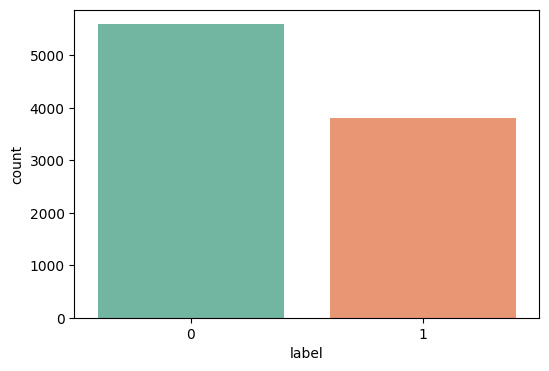

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train, palette='Set2')
plt.show()